# Deliverable #1: Explore Dataset

This notebook is to explore the selected dataset our ai4all project. 

**Dataset:** TON-IoT Network Dataset  
**Current project goal:** predict whether a record is normal or attack-related (predict the attack type depending on which target column is available.)

> Before running: place your dataset CSV file in the same folder as this notebook, then update `DATA_PATH` below.

In [136]:
# Core imports
import pandas as pd
import numpy as np

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
DATA_PATH = "train_test_network.csv"

df = pd.read_csv(DATA_PATH)

Action Items:
1. How many null values/missing values are there overall? Per column?
2. Are there any outlier values?
3. How many potential covariates/predictors can be used?
4. What is the dependent variable/thing being predicted by the model?
5. Visualizations (scatter plots, correlation matrices, bar charts, line graph, etc.) that explore relationships between the variables (with a slight focus on exploring the relationship between predictors and dependent variable)

## Dataset Overview

In [138]:
print(f"Dataset shape: {df.shape}")

print(f"Column names: {df.columns.tolist()}") #get column names as a list

display(df.head())

print("\nSummary of columns:")
display(df.describe().T)
display(df.describe(include='object').T)

Dataset shape: (211043, 44)
Column names: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor



Summary of columns:


,count,mean,std,min,25%,50%,75%,max
src_port,211043.0,38646.519543,1.930727e+04,1.0,34608.0,44754.00000,51133.000000,6.552800e+04
dst_port,211043.0,3495.153770,1.019162e+04,0.0,65.0,80.00000,1253.000000,6.546700e+04
duration,211043.0,7.700887,5.641419e+02,0.0,0.0,0.00017,0.054196,9.351693e+04
src_bytes,211043.0,258113.564274,1.709490e+07,0.0,0.0,0.00000,130.000000,3.890855e+09
dst_bytes,211043.0,258804.571575,1.802563e+07,0.0,0.0,0.00000,89.000000,3.913853e+09
missed_bytes,211043.0,34432.344295,5.261621e+06,0.0,0.0,0.00000,0.000000,1.854527e+09
src_pkts,211043.0,9.595220,9.177882e+01,0.0,1.0,1.00000,4.000000,2.462300e+04
src_ip_bytes,211043.0,776.082206,2.229703e+04,0.0,48.0,82.00000,415.000000,6.522626e+06
dst_pkts,211043.0,3.846861,3.307058e+02,0.0,0.0,1.00000,2.000000,1.219420e+05
dst_ip_bytes,211043.0,1584.686628,1.901795e+05,0.0,0.0,40.00000,134.000000,8.639552e+07


,count,unique,top,freq
src_ip,211043,51,192.168.1.30,61633
dst_ip,211043,753,192.168.1.190,47795
proto,211043,3,tcp,168747
service,211043,9,-,132032
conn_state,211043,13,S0,51937
dns_query,211043,726,-,176198
dns_AA,211043,3,-,176030
dns_RD,211043,3,-,176030
dns_RA,211043,3,-,176030
dns_rejected,211043,3,-,176030


## Null Values / Missing Values

- How many null values/missing values are there overall? 
- How many null values/missing values are there Per column?

## Identify the Dependent Variable

may include:
- `label`: often binary, such as normal vs attack
- `type`: often multiclass, such as normal, scanning, DoS, injection, etc.

In [139]:
dep_val = "label" # this is our dependent variable for the current project scope

## Potential Covariates / Predictors

Predictors are columns that could be used to predict the dependent variable.  

In [140]:
df.dtypes

src_ip                     object
src_port                    int64
dst_ip                     object
dst_port                    int64
proto                      object
service                    object
duration                  float64
src_bytes                   int64
dst_bytes                   int64
conn_state                 object
missed_bytes                int64
src_pkts                    int64
src_ip_bytes                int64
dst_pkts                    int64
dst_ip_bytes                int64
dns_query                  object
dns_qclass                  int64
dns_qtype                   int64
dns_rcode                   int64
dns_AA                     object
dns_RD                     object
dns_RA                     object
dns_rejected               object
ssl_version                object
ssl_cipher                 object
ssl_resumed                object
ssl_established            object
ssl_subject                object
ssl_issuer                 object
http_trans_dep

In [141]:
# Columns by type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'label']
Categorical columns: ['src_ip', 'dst_ip', 'proto', 'service', 'conn_state', 'dns_query', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'type']


In [142]:
target = ["label", "type"]
predictors = [col for col in df.columns if col in numerical_cols and col not in target]

print(predictors)

['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code']


## Outlier

checks numeric columns for outliers using the IQR rule.

A value is flagged as an outlier if it is:
- below Q1 - 1.5 × IQR, or
- above Q3 + 1.5 × IQR

## Visualizations

- scatter plots
- correlation matrices
    - correlation only captures linear relationships. For our project, we might need combination of feartures as the network attacks might not be detected by one simple feature.
- bar charts
- line graph, etc.

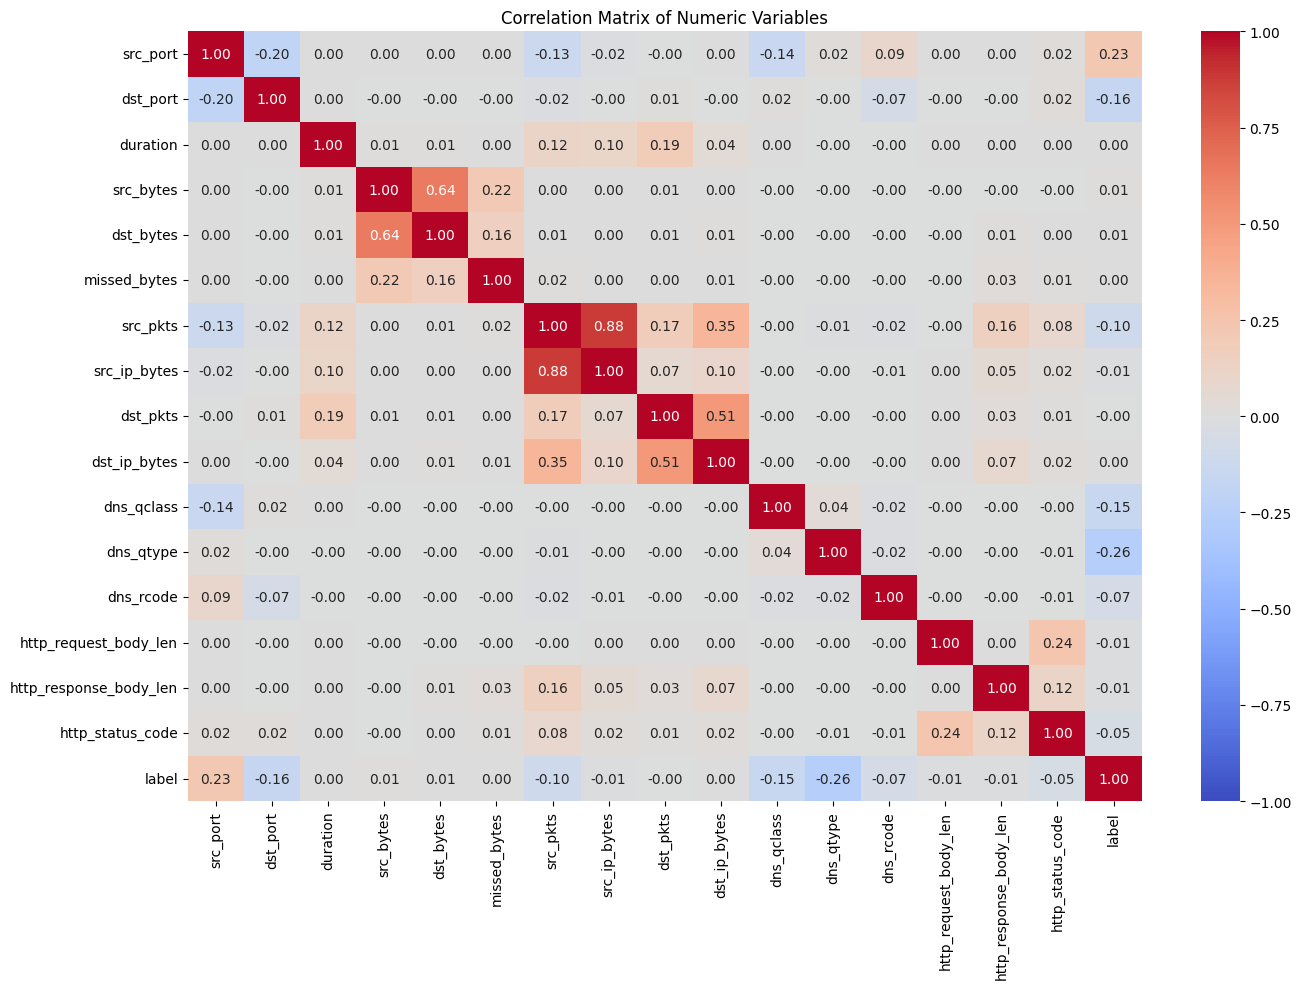

Correlation with target variable: label


label                     1.000000
dns_qtype                -0.261045
src_port                  0.226157
dst_port                 -0.156576
dns_qclass               -0.150112
src_pkts                 -0.102089
dns_rcode                -0.066729
http_status_code         -0.049023
http_request_body_len    -0.012701
src_ip_bytes             -0.010436
http_response_body_len   -0.008504
src_bytes                 0.008344
dst_bytes                 0.007698
duration                  0.003665
dst_pkts                 -0.003170
missed_bytes              0.002734
dst_ip_bytes              0.000707
Name: label, dtype: float64

In [143]:
# Correlation matrix for numeric columns
corr_matrix = df[numerical_cols].corr()
f = plt.figure(figsize=(14, 10))
# plt.matshow(corr_matrix, fignum=f.number)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", center=0)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

if dep_val in numerical_cols:
    target_corr = corr_matrix[dep_val].sort_values(ascending=False, key=abs)
    print(f"Correlation with target variable: {dep_val}")
    display(target_corr)